In [230]:
from linearmodels.panel import PanelOLS
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [129]:
# Daten laden
df = pd.read_csv("final_df.csv").rename(
    columns={"Unternehmensname Latin alphabet": "firma"}
)


In [248]:
# Differenz EKQ berechnen
df['dEKQ'] = df.groupby('firma')['EK_Quote'].diff()

In [250]:
# Nach Firma und Jahr sortieren
df = df.sort_values(['firma', 'Jahr']).copy()

In [252]:
# Wichtige Variablen Winsorisieren
cols_to_winsor = ['dEKQ', 'ROA', 'Cash_Ratio']

for col in cols_to_winsor:
    lower = df[col].quantile(0.01)
    upper = df[col].quantile(0.99)
    df[col] = df[col].clip(lower, upper)

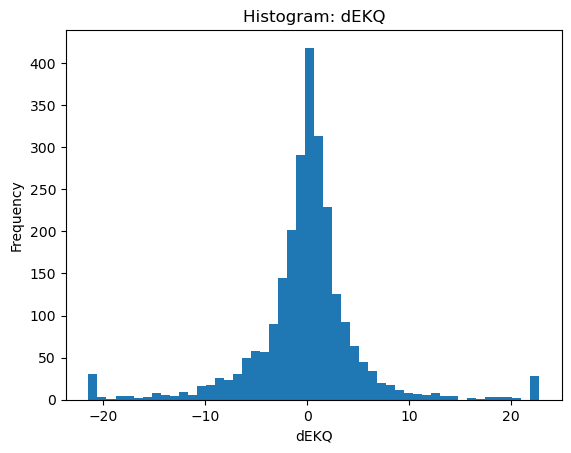

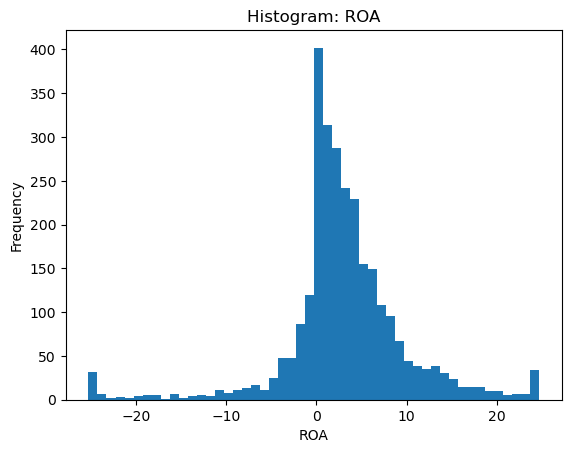

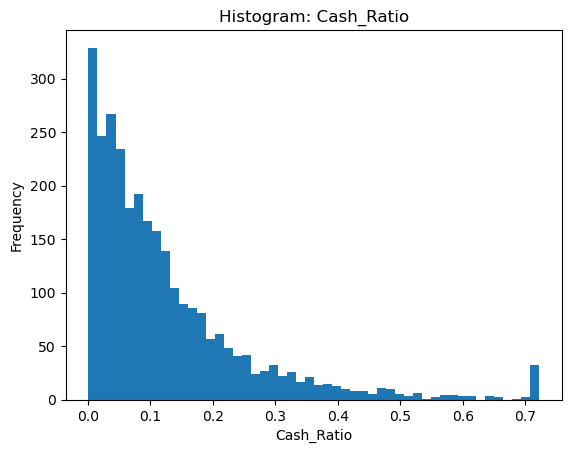

In [246]:
# Verteilung nach Winsorisierung betrachten

vars_to_plot = ['dEKQ', 'ROA', 'Cash_Ratio']

for var in vars_to_plot:
    plt.figure()
    plt.hist(df[var], bins=50)
    plt.title(f'Histogram: {var}')
    plt.xlabel(var)
    plt.ylabel('Frequency')
    plt.show()

In [244]:
# Simples Modell um zu schauen, ob Zinsschock einen eigenen Einfluss hat
modell_simp = smf.ols(
    formula="""
    EK_Quote ~ Zinsschock
             + Leverage_exante
             + Liquidity_exante
             + ROA
             + Groesse_Log_Bilanzsumme
             + Cash_Ratio
    """,
    data=df
).fit(
    cov_type="cluster",
    cov_kwds={"groups": df["firma"]}
)

print(modell_simp.summary())

                            OLS Regression Results                            
Dep. Variable:               EK_Quote   R-squared:                       0.856
Model:                            OLS   Adj. R-squared:                  0.855
Method:                 Least Squares   F-statistic:                     1193.
Date:                Thu, 14 May 2026   Prob (F-statistic):          7.60e-212
Time:                        08:25:32   Log-Likelihood:                -10132.
No. Observations:                2853   AIC:                         2.028e+04
Df Residuals:                    2846   BIC:                         2.032e+04
Df Model:                           6                                         
Covariance Type:              cluster                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

In [242]:
# Simples Modell um zu schauen, ob Zinswende einen eigenen Einfluss hat
modell_simp_zinswende = smf.ols(
    formula="""
    EK_Quote ~ Zinswende_Dummy
             + Leverage_exante
             + Liquidity_exante
             + ROA
             + Groesse_Log_Bilanzsumme
             + Cash_Ratio
    """,
    data=df
).fit(
    cov_type="cluster",
    cov_kwds={"groups": df["firma"]}
)

print(modell_simp_zinswende.summary())

                            OLS Regression Results                            
Dep. Variable:               EK_Quote   R-squared:                       0.856
Model:                            OLS   Adj. R-squared:                  0.855
Method:                 Least Squares   F-statistic:                     1130.
Date:                Thu, 14 May 2026   Prob (F-statistic):          2.53e-208
Time:                        08:25:28   Log-Likelihood:                -10131.
No. Observations:                2853   AIC:                         2.028e+04
Df Residuals:                    2846   BIC:                         2.032e+04
Df Model:                           6                                         
Covariance Type:              cluster                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

In [240]:
# Modell mit Niveau der EK_Quote
model_EKQ = smf.ols(
    'EK_Quote ~ Zinsschock + Zinsschock:Liquidity_exante + ROA + Groesse_Log_Bilanzsumme',
    data=df
).fit(cov_type='cluster', cov_kwds={'groups': df['firma']})

print(model_EKQ.summary())

                            OLS Regression Results                            
Dep. Variable:               EK_Quote   R-squared:                       0.045
Model:                            OLS   Adj. R-squared:                  0.044
Method:                 Least Squares   F-statistic:                     7.806
Date:                Thu, 14 May 2026   Prob (F-statistic):           5.24e-06
Time:                        08:25:24   Log-Likelihood:                -12826.
No. Observations:                2853   AIC:                         2.566e+04
Df Residuals:                    2848   BIC:                         2.569e+04
Df Model:                           4                                         
Covariance Type:              cluster                                         
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept         

In [254]:
# Variablen für die Regression mit dEKQ
reg_vars = [
    "dEKQ",
    "EK_Quote",
    "Zinsschock",
    "ABS",
    "Zinswende_Dummy",
    "Leverage_exante",
    "Liquidity_exante",
    "STDebtShare_exante",
    "ROA",
    "Groesse_Log_Bilanzsumme",
    "Cash_Ratio",
    "firma"
]

# Gemeinsamer Datensatz für alle Regressionen mit dEKQ
df_reg = df[reg_vars].dropna().copy()


In [256]:
# Regression mit Leverage
model_lev = smf.ols(
    'dEKQ ~ Zinsschock + Zinsschock:Leverage_exante + ROA + Groesse_Log_Bilanzsumme + Cash_Ratio',
    data=df_reg
).fit(
    cov_type='cluster',
    cov_kwds={'groups': df_reg['firma']}
)

print(model_lev.summary())

                            OLS Regression Results                            
Dep. Variable:                   dEKQ   R-squared:                       0.039
Model:                            OLS   Adj. R-squared:                  0.037
Method:                 Least Squares   F-statistic:                     9.427
Date:                Thu, 14 May 2026   Prob (F-statistic):           2.21e-08
Time:                        08:26:12   Log-Likelihood:                -7876.3
No. Observations:                2540   AIC:                         1.576e+04
Df Residuals:                    2534   BIC:                         1.580e+04
Df Model:                           5                                         
Covariance Type:              cluster                                         
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

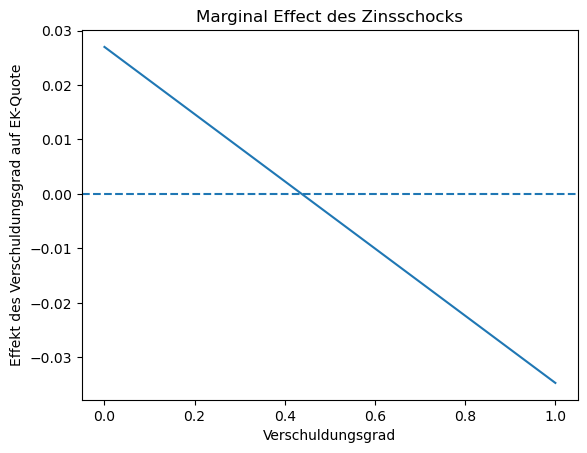

In [266]:
# Leverage-Modell
beta_z = 0.0270
beta_int = -0.0617

# Range für Leverage
x = np.linspace(0, 1, 100)

# Marginal Effect
effect = beta_z + beta_int * x

plt.plot(x, effect)
plt.axhline(0, linestyle='--')  # Null-Linie
plt.xlabel("Verschuldungsgrad")
plt.ylabel("Effekt des Verschuldungsgrad auf EK-Quote")
plt.title("Marginal Effect des Zinsschocks")

plt.savefig("Effekt_Leverage2.png", dpi=300)
plt.show()

In [258]:
# Regression mit Liquidity
model_liq = smf.ols(
    'dEKQ ~ Zinsschock + Zinsschock:Liquidity_exante + ROA + Groesse_Log_Bilanzsumme + Cash_Ratio',
    data=df_reg
).fit(
    cov_type='cluster',
    cov_kwds={'groups': df_reg['firma']}
)

print(model_liq.summary())

                            OLS Regression Results                            
Dep. Variable:                   dEKQ   R-squared:                       0.037
Model:                            OLS   Adj. R-squared:                  0.035
Method:                 Least Squares   F-statistic:                     8.482
Date:                Thu, 14 May 2026   Prob (F-statistic):           1.53e-07
Time:                        08:26:46   Log-Likelihood:                -7878.1
No. Observations:                2540   AIC:                         1.577e+04
Df Residuals:                    2534   BIC:                         1.580e+04
Df Model:                           5                                         
Covariance Type:              cluster                                         
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept         

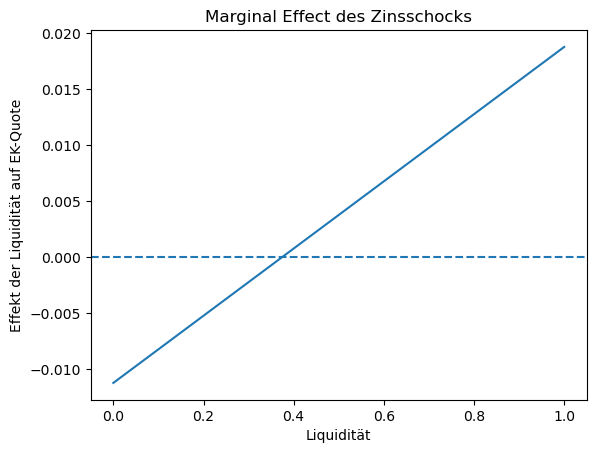

In [264]:
# Liquidity-Modell
beta_z = -0.0112
beta_int = 0.0300

# Range für Leverage
x = np.linspace(0, 1, 100)

# Marginal Effect
effect = beta_z + beta_int * x

plt.plot(x, effect)
plt.axhline(0, linestyle='--')  # Null-Linie
plt.xlabel("Liquidität")
plt.ylabel("Effekt der Liquidität auf EK-Quote")
plt.title("Marginal Effect des Zinsschocks")

plt.savefig("Effekt_Liquidity2.png", dpi=300)
plt.show()

In [260]:
# Regression mit STDebtShare
model_STDS = smf.ols(
    'dEKQ ~ Zinsschock + Zinsschock:STDebtShare_exante + ROA + Groesse_Log_Bilanzsumme + Cash_Ratio',
    data=df_reg
).fit(
    cov_type='cluster',
    cov_kwds={'groups': df_reg['firma']}
)

print(model_STDS.summary())

                            OLS Regression Results                            
Dep. Variable:                   dEKQ   R-squared:                       0.039
Model:                            OLS   Adj. R-squared:                  0.038
Method:                 Least Squares   F-statistic:                     10.72
Date:                Thu, 14 May 2026   Prob (F-statistic):           1.61e-09
Time:                        08:27:06   Log-Likelihood:                -7875.3
No. Observations:                2540   AIC:                         1.576e+04
Df Residuals:                    2534   BIC:                         1.580e+04
Df Model:                           5                                         
Covariance Type:              cluster                                         
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept     

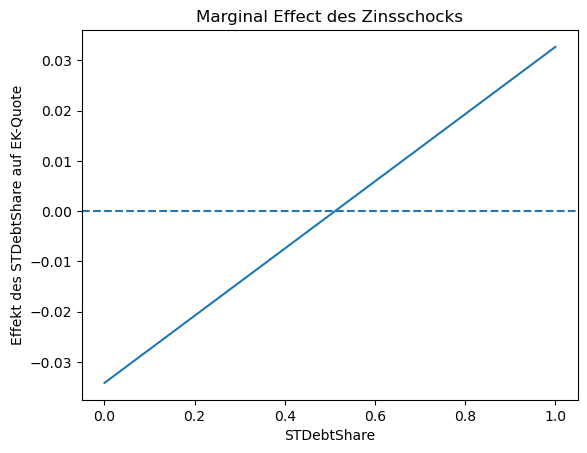

In [262]:
# STDebtShare-Modell
beta_z = -0.0342
beta_int = 0.0669

# Range für Leverage
x = np.linspace(0, 1, 100)

# Marginal Effect
effect = beta_z + beta_int * x

plt.plot(x, effect)
plt.axhline(0, linestyle='--')  # Null-Linie
plt.xlabel("STDebtShare")
plt.ylabel("Effekt des STDebtShare auf EK-Quote")
plt.title("Marginal Effect des Zinsschocks")

plt.savefig("Effekt_STDShare2.png", dpi=300)
plt.show()

In [268]:
# Regression mit Unternehmensgrösse
model_Gr = smf.ols(
    'dEKQ ~ Zinsschock + Zinsschock:Groesse_Log_Bilanzsumme + ROA + Cash_Ratio',
    data=df_reg
).fit(
    cov_type='cluster',
    cov_kwds={'groups': df_reg['firma']}
)

print(model_Gr.summary())

                            OLS Regression Results                            
Dep. Variable:                   dEKQ   R-squared:                       0.032
Model:                            OLS   Adj. R-squared:                  0.031
Method:                 Least Squares   F-statistic:                     8.638
Date:                Thu, 14 May 2026   Prob (F-statistic):           1.27e-06
Time:                        08:27:55   Log-Likelihood:                -7884.8
No. Observations:                2540   AIC:                         1.578e+04
Df Residuals:                    2535   BIC:                         1.581e+04
Df Model:                           4                                         
Covariance Type:              cluster                                         
                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Inte

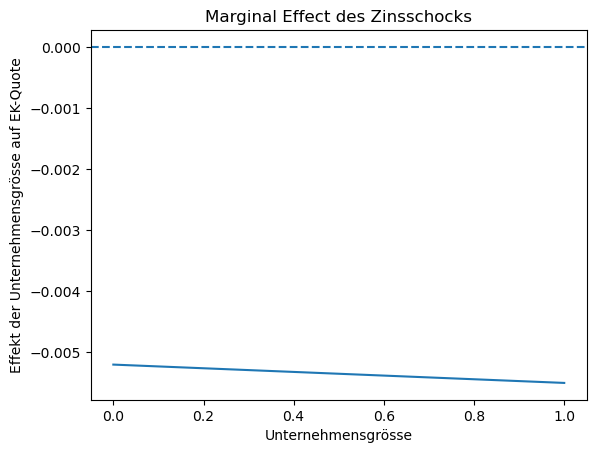

In [270]:
# Unternehmensgrösse-Modell
beta_z = -0.0052
beta_int = -0.0003

# Range für Leverage
x = np.linspace(0, 1, 100)

# Marginal Effect
effect = beta_z + beta_int * x

plt.plot(x, effect)
plt.axhline(0, linestyle='--')  # Null-Linie
plt.xlabel("Unternehmensgrösse")
plt.ylabel("Effekt der Unternehmensgrösse auf EK-Quote")
plt.title("Marginal Effect des Zinsschocks")

plt.savefig("Effekt_Grösse2.png", dpi=300)
plt.show()

In [272]:
# Modell mit finanziellen Interaktionstermen
modell_gemeinsam = smf.ols(
    formula="""
dEKQ ~ Zinsschock
      + Zinsschock:Leverage_exante
      + Zinsschock:Liquidity_exante
      + Zinsschock:STDebtShare_exante
      + ROA
      + Groesse_Log_Bilanzsumme
      + Cash_Ratio
    """,
    data=df
).fit(
    cov_type="cluster",
    cov_kwds={"groups": df_reg["firma"]}
)

print(modell_gemeinsam.summary())

                            OLS Regression Results                            
Dep. Variable:                   dEKQ   R-squared:                       0.040
Model:                            OLS   Adj. R-squared:                  0.037
Method:                 Least Squares   F-statistic:                     7.807
Date:                Thu, 14 May 2026   Prob (F-statistic):           1.03e-08
Time:                        08:28:43   Log-Likelihood:                -7874.6
No. Observations:                2540   AIC:                         1.577e+04
Df Residuals:                    2532   BIC:                         1.581e+04
Df Model:                           7                                         
Covariance Type:              cluster                                         
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept     

In [278]:
# Modell mit Absolutem Zinsschock
modell_abs = smf.ols(
    formula="""
    dEKQ ~ ABS
          + ABS:Leverage_exante
          + ROA
          + Groesse_Log_Bilanzsumme
          + Cash_Ratio
    """,
    data=df_reg
).fit(
    cov_type="cluster",
    cov_kwds={"groups": df_reg["firma"]}
)

print(modell_abs.summary())

                            OLS Regression Results                            
Dep. Variable:                   dEKQ   R-squared:                       0.055
Model:                            OLS   Adj. R-squared:                  0.053
Method:                 Least Squares   F-statistic:                     11.54
Date:                Thu, 14 May 2026   Prob (F-statistic):           3.08e-10
Time:                        08:29:36   Log-Likelihood:                -7855.1
No. Observations:                2540   AIC:                         1.572e+04
Df Residuals:                    2534   BIC:                         1.576e+04
Df Model:                           5                                         
Covariance Type:              cluster                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

In [280]:
# Modell mit Zinswende Dummy
modell_dum = smf.ols(
    formula="""
    dEKQ ~ Zinswende_Dummy
          + Zinswende_Dummy:Leverage_exante
          + ROA
          + Groesse_Log_Bilanzsumme
          + Cash_Ratio
    """,
    data=df_reg
).fit(
    cov_type="cluster",
    cov_kwds={"groups": df_reg["firma"]}
)

print(modell_dum.summary())

                            OLS Regression Results                            
Dep. Variable:                   dEKQ   R-squared:                       0.055
Model:                            OLS   Adj. R-squared:                  0.053
Method:                 Least Squares   F-statistic:                     11.49
Date:                Thu, 14 May 2026   Prob (F-statistic):           3.39e-10
Time:                        08:29:43   Log-Likelihood:                -7855.1
No. Observations:                2540   AIC:                         1.572e+04
Df Residuals:                    2534   BIC:                         1.576e+04
Df Model:                           5                                         
Covariance Type:              cluster                                         
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept 